In [1]:
1+1

2

In [2]:
import langchain

In [3]:
import os
from langchain.chat_models import init_chat_model
os.environ['groq_api_key'] = os.getenv('groq_api_key')

In [4]:
model = init_chat_model("groq:qwen/qwen3-32b")

In [5]:
response = model.invoke('y do parrots talk so much?')

In [9]:
print(response.content)

<think>
Okay, so the user is asking why parrots talk so much. Let me start by recalling what I know about parrots. Parrots are known for their ability to mimic human speech, right? But why do they do it so much?

First, I should consider their natural behavior. In the wild, parrots are social animals. They live in flocks, so communication would be important for them. Maybe talking is a way to bond with their flock or to signal location and safety. Since they're social, they might have evolved to use vocalizations as a key part of their interactions.

Then there's the aspect of mimicry. Parrots are among the few birds that can mimic sounds, including human speech. But why do they mimic? Is it just a learned behavior, or is there a deeper reason? Maybe it's a way to integrate into a social group. In the wild, young parrots learn to mimic their parents' calls. In captivity, they might mimic their human caregivers because they see humans as part of their social group.

Another angle is the

In [11]:
from langchain.tools import tool

In [ ]:
@tool
def get_wether(loc:str)->str:
    """get the wether at a location"""
    return f"its rainy at {loc}"

In [26]:
model_with_tools = model.bind_tools([get_wether])

In [27]:
response = model_with_tools.invoke("What's the weather like in Boston?")
print(response.content)

In [22]:
response

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about the weather in Boston. Let me check the tools available. There\'s a function called get_wether that takes a location parameter. The required parameter is "loc" of type string. Since the user mentioned Boston, I need to call this function with "Boston" as the location. I should make sure the JSON is correctly formatted with the name of the function and the arguments. Let me structure the tool call accordingly.\n', 'tool_calls': [{'id': 'r4bhkrxea', 'function': {'arguments': '{"loc":"Boston"}', 'name': 'get_wether'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 156, 'total_tokens': 272, 'completion_time': 0.175479892, 'completion_tokens_details': {'reasoning_tokens': 91}, 'prompt_time': 0.007137175, 'prompt_tokens_details': None, 'queue_time': 0.157460094, 'total_time': 0.182617067}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp

In [23]:
for tool_call in response.tool_calls:
    # View tool calls made by the model
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

Tool: get_wether
Args: {'loc': 'Boston'}


In [30]:

# Step 1: Model generates tool calls
messages = [{"role": "user", "content": "What's the weather in Boston?"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

# Step 2: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    # Execute the tool with the generated arguments
    tool_result = get_wether.invoke(tool_call)
    messages.append(tool_result)

# Step 3: Pass results back to model for final response
final_response = model_with_tools.invoke(messages)
print(final_response.text)
# "The current weather in Boston is 72°F and sunny."


The weather in Boston is currently rainy. You might want to carry an umbrella if you're heading out! 🌧️


In [31]:
messages 

[{'role': 'user', 'content': "What's the weather in Boston?"},
 AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the weather in Boston. Let me check the tools available. There\'s a function called get_wether that takes a location parameter. The required parameter is "loc", which should be a string. Since the user mentioned Boston, I need to call get_wether with "Boston" as the loc argument. I\'ll make sure to format the tool call correctly within the XML tags.\n', 'tool_calls': [{'id': 'pappt09vj', 'function': {'arguments': '{"loc":"Boston"}', 'name': 'get_wether'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 108, 'prompt_tokens': 155, 'total_tokens': 263, 'completion_time': 0.147295086, 'completion_tokens_details': {'reasoning_tokens': 83}, 'prompt_time': 0.006233259, 'prompt_tokens_details': None, 'queue_time': 0.045792691, 'total_time': 0.153528345}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'f

# create agent

In [33]:
from langchain.agents import create_agent

In [34]:

def get_wether(loc:str)->str:
    """get the wether at a location"""
    return f"its rainy at {loc}"

In [35]:
agent = create_agent(
    model = "groq:qwen/qwen3-32b",
    tools = [get_wether],
    system_prompt = "you are a helpful assistant"

)

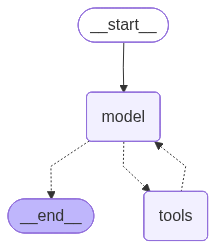

In [36]:
agent

In [37]:
agent.stream('wether in delhi?')

<generator object Pregel.stream at 0x00000223053AD600>

In [39]:
response=agent.invoke({"messages":[{"role":"user","content":"What is the weather like in New York?"}]})


In [40]:
response['messages']

[HumanMessage(content='What is the weather like in New York?', additional_kwargs={}, response_metadata={}, id='ab4ba99d-4726-4ff8-9e62-50e38e044885'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about the weather in New York. Let me check the tools available. There\'s a function called get_wether that takes a location parameter. The required parameter is "loc" of type string. Since the user mentioned New York, I should call get_wether with loc set to "New York". I need to make sure the JSON is correctly formatted with the name and arguments. Let me structure the tool_call accordingly.\n', 'tool_calls': [{'id': '0qpz9q1fb', 'function': {'arguments': '{"loc":"New York"}', 'name': 'get_wether'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 163, 'total_tokens': 279, 'completion_time': 0.16870072, 'completion_tokens_details': {'reasoning_tokens': 90}, 'prompt_time': 0.007255341, 'prompt_toke

In [41]:
agent.invoke({"messages":"What is the weather in New Yourk"})

{'messages': [HumanMessage(content='What is the weather in New Yourk', additional_kwargs={}, response_metadata={}, id='d4d5950c-fc52-4c00-8b51-d863b2073cbc'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the weather in New York. Let me check the tools available. There\'s a function called get_wether that takes a location parameter. The user spelled "New Yourk" with a typo, but I should use the correct spelling "New York" when calling the function. I\'ll make sure to pass the right location so the weather data is accurate. Let me structure the tool call properly.\n', 'tool_calls': [{'id': 'xyz1qpx50', 'function': {'arguments': '{"loc":"New York"}', 'name': 'get_wether'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 112, 'prompt_tokens': 162, 'total_tokens': 274, 'completion_time': 0.192643143, 'completion_tokens_details': {'reasoning_tokens': 86}, 'prompt_time': 0.007682905, 'prompt_tokens_details': None,

# google serp api key example 

In [47]:
from langchain.chat_models import init_chat_model
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.tools import tool
from langchain.agents import create_agent


os.environ['groq_api_key'] = os.getenv('groq_api_key')

model = init_chat_model("groq:qwen/qwen3-32b", temperature=0)
search = GoogleSerperAPIWrapper()


@tool
def intermediate_answer(query: str) -> str:
    """Useful for when you need to ask with search."""
    return search.run(query)


tools = [intermediate_answer]
agent = create_agent(model, tools)

events = agent.stream(
    {
        "messages": [
            ("user", "What is the hometown of the reigning men's U.S. Open champion?")
        ]
    },
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What is the hometown of the reigning men's U.S. Open champion?
================================== Ai Message ==================================

The hometown of the reigning men's U.S. Open champion, Novak Djokovic, is Belgrade, Serbia.


In [51]:
os.environ["SERPER_API_KEY"] = ""

In [44]:
import pprint

In [45]:
from langchain_community.utilities import GoogleSerperAPIWrapper

search = GoogleSerperAPIWrapper()

In [46]:
search.run("Obama's first name?")

"Barack Hussein Obama II (born August 4, 1961) is an American politician who served as the 44th president of the United States from 2009 to 2017. Barack Hussein Obama II was born August 4, 1961, in Honolulu, Hawaii, to parents Barack H. Obama, Sr., and Stanley Ann Dunham. Barack Hussein Obama II was born on August 4, 1961, in Hawaii. His parents, who met as students at the University of Hawaii, were Ann Dunham, a white American ... Barack H. Obama is the 44th President of the United States. His story is the American story — values from the heartland, a middle-class upbringing in a ... In full: Barack Hussein Obama II · Born: August 4, 1961, Honolulu, Hawaii, U.S. (age 64) · Title / Office: presidency of the United States of ... When Barack Obama was elected president in 2008, he became the first African American to hold the office. Obama faced major challenges during his two-term tenur President Barack Hussein Obama is a Black man with a medium warm skin tone, and. Photo by Pari Dukovi

# obtaining results with metadata 

In [48]:
search = GoogleSerperAPIWrapper()
results = search.results("Apple Inc.")
pprint.pp(results)

{'searchParameters': {'q': 'Apple Inc.',
                      'gl': 'us',
                      'hl': 'en',
                      'type': 'search',
                      'num': 10,
                      'engine': 'google'},
 'organic': [{'title': 'Apple',
              'link': 'https://www.apple.com/',
              'snippet': 'Discover the innovative world of Apple and shop '
                         'everything iPhone, iPad, Apple Watch, Mac, and Apple '
                         'TV, plus explore accessories, entertainment, ...',
              'sitelinks': [{'title': 'Careers at Apple',
                             'link': 'https://www.apple.com/careers/us/'},
                            {'title': 'Store',
                             'link': 'https://www.apple.com/store'},
                            {'title': 'Newsroom',
                             'link': 'https://www.apple.com/newsroom/'},
                            {'title': 'Business',
                             'link': 'h

# searching for images

In [49]:
search = GoogleSerperAPIWrapper(type="images")
results = search.results("Lion")
pprint.pp(results)

{'searchParameters': {'q': 'Lion',
                      'gl': 'us',
                      'hl': 'en',
                      'type': 'images',
                      'num': 10,
                      'engine': 'google'},
 'images': [{'title': 'Lion - Wikipedia',
             'imageUrl': 'https://upload.wikimedia.org/wikipedia/commons/a/a6/020_The_lion_king_Snyggve_in_the_Serengeti_National_Park_Photo_by_Giles_Laurent.jpg',
             'imageWidth': 5168,
             'imageHeight': 3448,
             'thumbnailUrl': 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQum62NWJbpa3uqr6ozh7yZxE_sM2prsZCsVg&s',
             'thumbnailWidth': 275,
             'thumbnailHeight': 183,
             'source': 'Wikipedia',
             'domain': 'en.wikipedia.org',
             'link': 'https://en.wikipedia.org/wiki/Lion',
             'googleUrl': 'https://www.google.com/imgres?imgurl=https%3A%2F%2Fupload.wikimedia.org%2Fwikipedia%2Fcommons%2Fa%2Fa6%2F020_The_lion_king_Snyggve_in_the_Serenge

# search for news

In [50]:
search = GoogleSerperAPIWrapper(type="news")
results = search.results("Tesla Inc.")
pprint.pp(results)

{'searchParameters': {'q': 'Tesla Inc.',
                      'gl': 'us',
                      'hl': 'en',
                      'type': 'news',
                      'num': 10,
                      'page': 1,
                      'allowSuggested': True,
                      'engine': 'google'},
 'news': [{'title': 'Tesla Finance VP Exits in Latest Departure for Musk’s EV '
                    'Maker',
           'link': 'https://www.bloomberg.com/news/articles/2026-03-09/tesla-finance-vp-exits-in-latest-departure-for-musk-s-ev-maker',
           'snippet': 'A longtime Tesla Inc. executive is leaving the Elon '
                      'Musk-run electric vehicle company, extending a string '
                      'of departures as the manufacturer...',
           'date': '10 hours ago',
           'source': 'Bloomberg.com',
           'imageUrl': 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRjAyw1Lc2VOiHwrGp8sO8UF9JBzhD-HL3zKXXED1NuSQ5NQsWY4drNR2k&usqp=CAI&s'},
          {'